## Black-Scholes greeks plots

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from black_scholes.closed import black_scholes, delta, gamma, theta

from config.plot_settings import *

In [2]:
r = 0
sigma = 0.3
K = 1.0

In [3]:
T_range = np.array([0.1, 0.25, 0.5, 0.75, 1.0])
S_range = np.linspace(0.3, 1.7, 100)

shape = (len(T_range), len(S_range))

deltas = np.zeros(shape)
gammas = np.zeros(shape)
thetas = np.zeros(shape)
prices = np.zeros(shape)

for i, T in enumerate(T_range):
    deltas[i, :] = delta(S_range, K, r, T, sigma, option_type='put')
    gammas[i, :] = gamma(S_range, K, r, T, sigma, option_type='put')
    thetas[i, :] = theta(S_range, K, r, T, sigma, option_type='put')
    prices[i, :] = black_scholes(S_range, K, r, T, sigma, option_type='put')


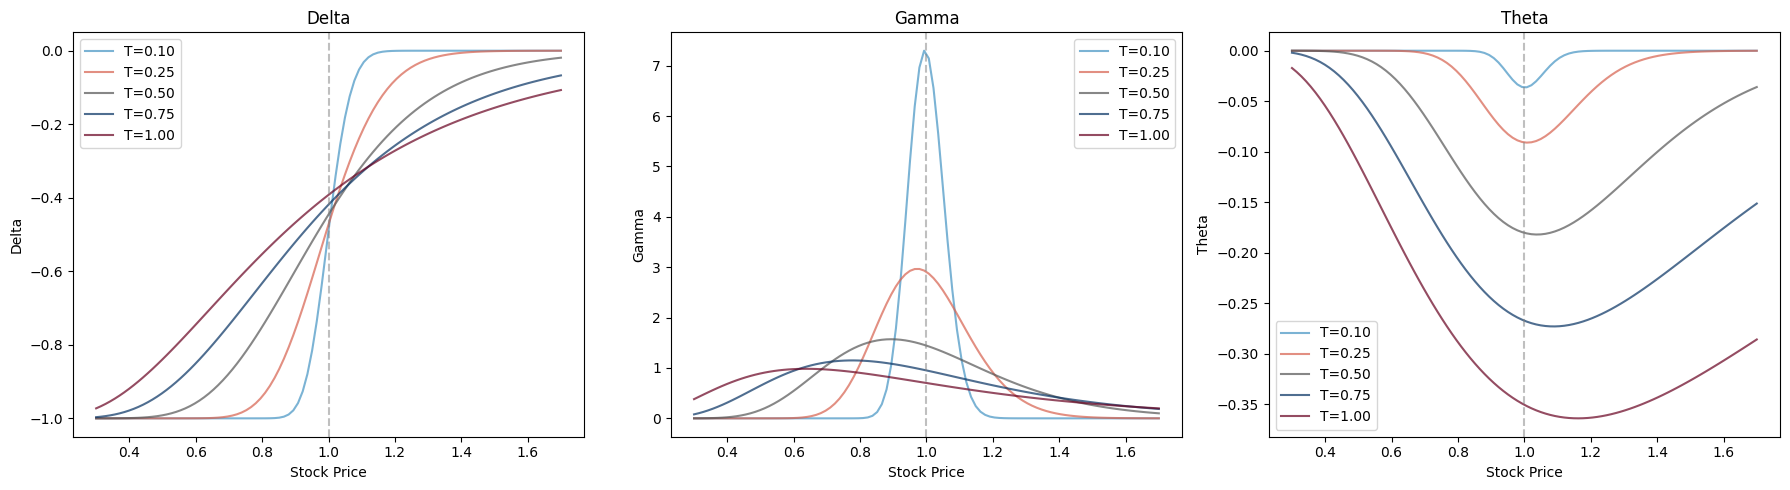

In [4]:
plt.figure(figsize=figsize3)

for i, T in enumerate(T_range):
    plt.subplot(1, 3, 1)
    plt.plot(S_range, deltas[i, :], label=f'T={T:.2f}', alpha=0.7)
    plt.subplot(1, 3, 2)
    plt.plot(S_range, gammas[i, :], label=f'T={T:.2f}', alpha=0.7)
    plt.subplot(1, 3, 3)
    plt.plot(S_range, thetas[i, :], label=f'T={T:.2f}', alpha=0.7)

plt.subplot(1, 3, 1)
plt.axvline(K, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Stock Price')
plt.ylabel('Delta')
plt.title('Delta')
plt.legend()

plt.subplot(1, 3, 2)
plt.axvline(K, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Stock Price')
plt.ylabel('Gamma')
plt.title('Gamma')
plt.legend()

plt.subplot(1, 3, 3)
plt.axvline(K, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Stock Price')
plt.ylabel('Theta')
plt.title('Theta')
plt.legend()

plt.tight_layout()
plt.show()